In [2]:
# check kernel is pointing to HENS venv
import sys
print(sys.executable)

/home/ubuntu/projects/earth2studio/recipes/hens/.venv/bin/python


In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [4]:
!pwd

/home/ubuntu/projects/earth2studio/recipes/hens/notebooks


In [5]:
houston = xr.open_dataset('../outputs_beryl_poc/houston/beryl-poc_2024-07-06T00_pkg_registry.nc')

In [6]:
houston['w10m'] = np.sqrt(houston['u10m'] ** 2 + houston['v10m'] ** 2)

In [7]:
houston

<xarray.Dataset> Size: 108kB
Dimensions:    (ensemble: 2, time: 1, lead_time: 2, lat: 41, lon: 41)
Coordinates:
  * ensemble   (ensemble) int64 16B 0 1
  * time       (time) datetime64[ns] 8B 2024-07-06
  * lead_time  (lead_time) timedelta64[ns] 16B 00:00:00 06:00:00
  * lat        (lat) float64 328B 35.0 34.75 34.5 34.25 ... 25.5 25.25 25.0
  * lon        (lon) float64 328B 260.0 260.2 260.5 260.8 ... 269.5 269.8 270.0
Data variables:
    u10m       (ensemble, time, lead_time, lat, lon) float32 27kB -2.605 ... ...
    v10m       (ensemble, time, lead_time, lat, lon) float32 27kB 2.395 ... -...
    msl        (ensemble, time, lead_time, lat, lon) float32 27kB ...
    w10m       (ensemble, time, lead_time, lat, lon) float32 27kB 3.538 ... 9...

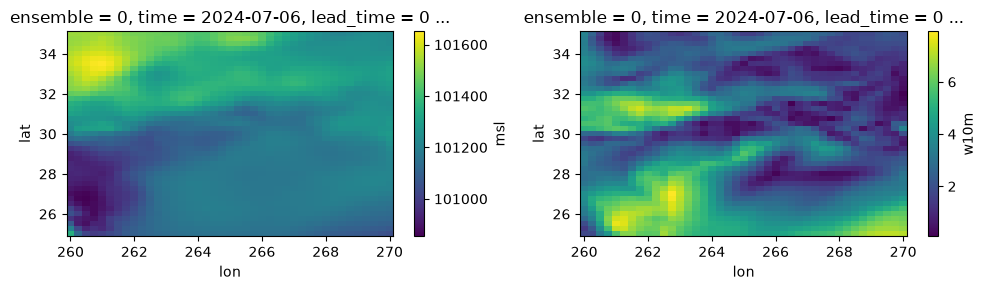

In [8]:
fig, ax = plt.subplots(1,2, figsize=(10,3))
houston['msl'].isel(ensemble=0, lead_time=0, time=0).plot(ax=ax[0])
houston['w10m'].isel(ensemble=0, lead_time=0, time=0).plot(ax=ax[1])
plt.tight_layout()

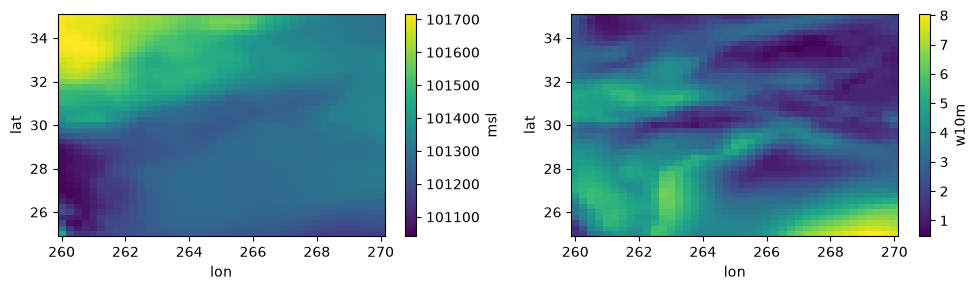

In [9]:
fig, ax = plt.subplots(1,2, figsize=(10,3))
houston['msl'].mean(['time', 'lead_time', 'ensemble']).plot(ax=ax[0])
houston['w10m'].mean(['time', 'lead_time', 'ensemble']).plot(ax=ax[1])
plt.tight_layout()

In [33]:
track = xr.open_dataset('../outputs_beryl_poc/cyclones/tracks_pkg_hens_model_registry_2024-07-06T00:00:00_batch_0.nc')["__xarray_dataarray_variable__"]

In [34]:
track

<xarray.DataArray '__xarray_dataarray_variable__' (ensemble: 2, time: 1,
                                                   path_id: 8, step: 2,
                                                   variable: 4)> Size: 1kB
[128 values with dtype=float64]
Coordinates:
  * ensemble  (ensemble) int64 16B 0 1
  * time      (time) datetime64[ns] 8B 2024-07-06
  * path_id   (path_id) int64 64B 0 1 2 3 4 5 6 7
  * step      (step) int64 16B 0 1
  * variable  (variable) <U6 96B 'tclat' 'tclon' 'tcmsl' 'tcw10m'

In [35]:
print(track)

<xarray.DataArray '__xarray_dataarray_variable__' (ensemble: 2, time: 1,
                                                   path_id: 8, step: 2,
                                                   variable: 4)> Size: 1kB
[128 values with dtype=float64]
Coordinates:
  * ensemble  (ensemble) int64 16B 0 1
  * time      (time) datetime64[ns] 8B 2024-07-06
  * path_id   (path_id) int64 64B 0 1 2 3 4 5 6 7
  * step      (step) int64 16B 0 1
  * variable  (variable) <U6 96B 'tclat' 'tclon' 'tcmsl' 'tcw10m'


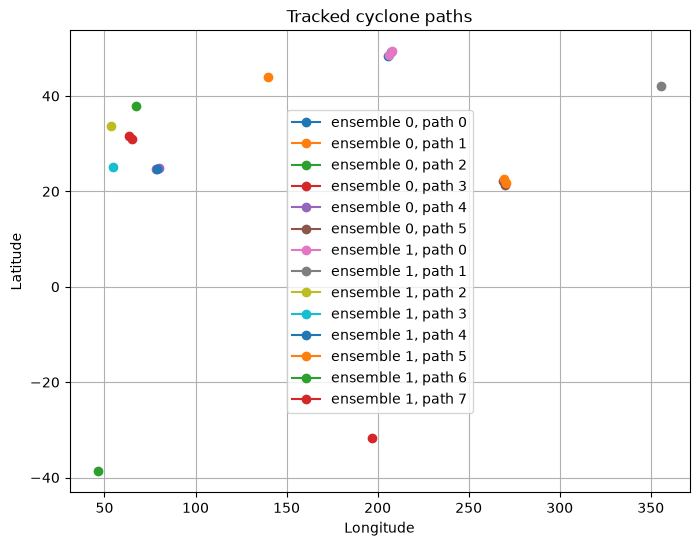

In [36]:
import matplotlib.pyplot as plt

lat = track.sel(variable="tclat")
lon = track.sel(variable="tclon")

fig, ax = plt.subplots(figsize=(8, 6))

for ensemble in lat.ensemble.values:
    for path_id in lat.path_id.values:
        x = np.atleast_1d(
            lon.sel(ensemble=ensemble, path_id=path_id).values
        ).astype(float)

        y = np.atleast_1d(
            lat.sel(ensemble=ensemble, path_id=path_id).values
        ).astype(float)

        valid = np.isfinite(x) & np.isfinite(y)

        if np.any(valid):
            ax.plot(
                x[valid],
                y[valid],
                marker="o",
                label=f"ensemble {ensemble}, path {path_id}",
            )

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Tracked cyclone paths")
ax.grid(True)
ax.legend()
plt.show()

In [32]:
# print(lon.dtype)
# print(lat.dtype)
print(lon.values)
print(lat.values)

<bound method Mapping.values of <xarray.Dataset> Size: 384B
Dimensions:                        (ensemble: 2, time: 1, path_id: 8, step: 2)
Coordinates:
  * ensemble                       (ensemble) int64 16B 0 1
  * time                           (time) datetime64[ns] 8B 2024-07-06
  * path_id                        (path_id) int64 64B 0 1 2 3 4 5 6 7
  * step                           (step) int64 16B 0 1
    variable                       <U6 24B 'tclon'
Data variables:
    __xarray_dataarray_variable__  (ensemble, time, path_id, step) float64 256B ...>
<bound method Mapping.values of <xarray.Dataset> Size: 384B
Dimensions:                        (ensemble: 2, time: 1, path_id: 8, step: 2)
Coordinates:
  * ensemble                       (ensemble) int64 16B 0 1
  * time                           (time) datetime64[ns] 8B 2024-07-06
  * path_id                        (path_id) int64 64B 0 1 2 3 4 5 6 7
  * step                           (step) int64 16B 0 1
    variable                

In [30]:
track.__xarray_dataarray_variable__.sel(variable='tclon').values

array([[[[207.40175927, 205.89551094],
         [139.82694014,          nan],
         [ 67.4489106 ,          nan],
         [ 65.25177328,  63.22091076],
         [ 78.46709019,  79.70068918],
         [270.18395417, 269.07109514],
         [         nan,          nan],
         [         nan,          nan]]],


       [[[207.73789607, 206.3105882 ],
         [355.86452971,          nan],
         [ 53.55139309,          nan],
         [ 54.75910803,          nan],
         [ 78.81482891,          nan],
         [270.36674219, 269.14594394],
         [ 46.32431269,          nan],
         [         nan, 196.93361112]]]])

In [22]:
valid

-1